# SWIFT Town/Country Retraction Experiment Analysis

**What this is.** A read-only look at how the *current* deterministic retraction rule behaved on
115 deliberately awkward, unstructured address records — the ones where an organisation name
carries a town or country word (`CITIBANK LONDON`, `NATIONAL BANK OF CANADA`, …).

**How the artifacts were produced.** Town/Country extraction came from the existing Gemini
pipeline, unchanged. Retraction — taking the verified Town and Country evidence back out of the
source lines — is deterministic Python in `models/swft_tc/src/retraction.py`: at most one
right-most Town occurrence per group, every verified Country occurrence. Nothing in this notebook
re-runs either step; it only reads what the batch wrote.

**Why.** To establish the baseline before any entity-aware protection is evaluated. The review
cohorts built below are where that evaluation should be pointed.

> **This notebook evaluates retraction behavior and review patterns. It does not claim production
> accuracy without independently labeled ground truth.** Rows are described as *observed behavior*,
> *retraction outcome*, *review candidate* or *reference-supported* — never as correct or incorrect
> unless the pipeline itself recorded deterministic evidence for that specific statement.

## 2 — Environment and paths

Same bootstrap as the pipeline notebooks: walk up from the working directory to the repository
root (identified by its `pytest.ini` and `models/`), put that one directory on the import path,
and derive every other location from the package and the experiment configuration. No absolute
path appears anywhere, so this runs from the repository root or from `notebooks/swft_tc/`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pytest.ini").is_file() and (candidate / "models").is_dir():
            return candidate
    raise RuntimeError(
        f"Could not locate the repository root from {start}: expected an ancestor "
        "containing pytest.ini and models/."
    )


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from models.swft_tc.src.settings import MODEL_ROOT, load_config

# Every artifact location comes from the experiment configuration — the same
# file the batch ran with — so the notebook follows the config, not guesses.
EXPERIMENT_CONFIG = MODEL_ROOT / "config" / "config_retraction_experiment.yaml"
config = load_config(EXPERIMENT_CONFIG, base_dir=MODEL_ROOT)
OUTPUT_ROOT = MODEL_ROOT / "outputs"
GROUP = "1"

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 220)

print("repository root :", REPO_ROOT)
print("model root      :", MODEL_ROOT.relative_to(REPO_ROOT))
print("output directory:", OUTPUT_ROOT.relative_to(REPO_ROOT))
print("experiment cfg  :", EXPERIMENT_CONFIG.relative_to(REPO_ROOT))

repository root : /Users/krishnakumar/special_projects/swift_tc
model root      : models/swft_tc
output directory: models/swft_tc/outputs
experiment cfg  : models/swft_tc/config/config_retraction_experiment.yaml


## 3 — Load experiment artifacts

Required: the canonical output CSV, the detailed JSONL audit and the run metrics. Optional: the
two review CSVs the builder script derives. Missing optional files are reported, not fatal; a
missing required file prints a friendly message and the analysis cells below stand down.

In [2]:
NOT_READY = (
    "Experiment output is not available yet. Complete the batch run "
    "(see README → Retraction experiment) and rerun this cell."
)

PATHS = {
    "output_csv": config.path(config.processing.output_path),
    "detailed_jsonl": config.path(config.processing.detailed_json_path),
    "metrics_json": config.path(config.processing.metrics_path),
    "reports_dir": config.path(config.reporting.reports_dir),
    "charts_dir": config.path(config.reporting.charts_dir),
}
_prefix = PATHS["output_csv"].stem.removesuffix("_output")
PATHS["retraction_review_csv"] = PATHS["output_csv"].parent / f"{_prefix}_retraction_review.csv"
PATHS["town_in_line1_csv"] = PATHS["output_csv"].parent / f"{_prefix}_town_in_line1_review.csv"
REQUIRED = ("output_csv", "detailed_jsonl", "metrics_json")


def _rel(path: Path) -> str:
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


for name, path in PATHS.items():
    tag = "required" if name in REQUIRED else "optional"
    print(f"{'present' if path.exists() else 'absent ':8} {tag:8} {_rel(path)}")

df = detail = metrics = None
review_df = line1_df = None
missing_required = [n for n in REQUIRED if not PATHS[n].exists()]
if missing_required:
    print(f"\n{NOT_READY}\nMissing: {', '.join(missing_required)}")
else:
    df = pd.read_csv(PATHS["output_csv"], dtype=str, keep_default_na=False, encoding="utf-8-sig")
    with PATHS["detailed_jsonl"].open(encoding="utf-8") as fh:
        detail = [json.loads(line) for line in fh if line.strip()]
    metrics = json.loads(PATHS["metrics_json"].read_text(encoding="utf-8"))
    if PATHS["retraction_review_csv"].exists():
        review_df = pd.read_csv(PATHS["retraction_review_csv"], dtype=str, keep_default_na=False)
    if PATHS["town_in_line1_csv"].exists():
        line1_df = pd.read_csv(PATHS["town_in_line1_csv"], dtype=str, keep_default_na=False)
    print(f"\nloaded: {len(df)} output rows, {len(detail)} detailed records, metrics for run "
          f"{metrics.get('run', {}).get('started_at_utc', '?')}")


def ready() -> bool:
    """True when the required artifacts loaded; otherwise print why and stand down."""
    if df is None:
        print(NOT_READY)
        return False
    return True

present  required models/swft_tc/outputs/retraction_experiment_output.csv
present  required models/swft_tc/outputs/retraction_experiment_detailed_output.jsonl
present  required models/swft_tc/outputs/retraction_experiment_run_metrics.json
present  optional models/swft_tc/outputs/retraction_experiment/reports
present  optional models/swft_tc/outputs/retraction_experiment/charts
present  optional models/swft_tc/outputs/retraction_experiment_retraction_review.csv
present  optional models/swft_tc/outputs/retraction_experiment_town_in_line1_review.csv

loaded: 115 output rows, 115 detailed records, metrics for run 2026-10-03T16:36:59+00:00


### Helpers

Column names come from the configuration's naming templates, so the notebook never spells a
production column by hand. Booleans in the CSV are the strings `True`/`False`; the helpers keep
that conversion in one place.

In [3]:
RECORD_ID = config.project.record_id_column
SOURCE_FIELDS = ["address_line_1", "address_line_2", "address_line_3", "address_line_4"]


def col(key: str) -> str:
    """Production column name for one output field of the configured group."""
    return config.output.column_name(key, GROUP)


def as_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().eq("true")


def as_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def pct(count: int, total: int) -> str:
    return f"{count} ({100.0 * count / total:.1f}%)" if total else "0"


def show(frame: pd.DataFrame, n: int = 10, **kwargs) -> None:
    """Display up to n rows; say how many there were in total."""
    print(f"{len(frame)} row(s){' — showing ' + str(n) if len(frame) > n else ''}")
    if len(frame):
        display(frame.head(n), **kwargs)


ADDRESS_VIEW = [RECORD_ID, *SOURCE_FIELDS]
C = {k: col(k) for k in (
    "combined_address", "combined_address_cleaned", "predicted_town", "predicted_country",
    "predicted_country_name", "predicted_town_probability", "predicted_country_probability",
    "predicted_town_exists", "predicted_country_exists", "composite_weighted_score",
    "rationale_town", "rationale_country", "town_exists_ok", "country_exists_ok",
    "cross_entropy", "combined_address_retracted", "combined_address_retracted_comments",
    "hitl_flag", "hitl_state", "hitl_state_reason",
)}
print("example resolved columns:", C["predicted_town"], "|", C["combined_address_retracted"])

example resolved columns: predicted_town_group_1 | combined_address_retracted_group_1


## 4 — Run summary

Counts come from the run metrics the pipeline wrote wherever they exist there; only the
retraction split is derived from the output itself.

In [4]:
if ready():
    run, shape, eff, out = (metrics.get(k, {}) for k in ("run", "shape", "efficiency", "outcomes"))
    hitl_flag = as_bool(df[C["hitl_flag"]])
    changed = df[C["combined_address_cleaned"]].ne(df[C["combined_address_retracted"]])
    summary = pd.DataFrame(
        [
            ("Input records", shape.get("input_rows")),
            ("Output records", len(df)),
            ("Output columns", len(df.columns)),
            ("Unique RECORD_ID", df[RECORD_ID].nunique()),
            ("Processing errors (unique addresses)", out.get("extraction_errors")),
            ("Backend model calls", eff.get("backend_calls")),
            ("Cache hits", eff.get("cache_hits")),
            ("Model", run.get("model")),
            ("Run mode", run.get("mode")),
            ("Prompt version", run.get("prompt_version")),
            ("HITL rows", int(hitl_flag.sum())),
            ("Auto-accept candidate rows", int((~hitl_flag).sum())),
            ("Retraction changed the address", int(changed.sum())),
            ("No retraction change", int((~changed).sum())),
        ],
        columns=["metric", "value"],
    )
    display(summary)

,metric,value
0,Input records,115
1,Output records,115
2,Output columns,25
3,Unique RECORD_ID,115
4,Processing errors (unique addresses),0
5,Backend model calls,116
6,Cache hits,0
7,Model,gemini-3.5-flash
8,Run mode,live
9,Prompt version,v6-lima-postal-inference


## 5 — Output contract

One configured group, so the canonical width is the 5 source columns plus the 20 generated fields.
The check reports what is present, missing and extra rather than failing, so a deliberate schema
evolution shows up as information.

In [5]:
if ready():
    expected = [RECORD_ID, *SOURCE_FIELDS, *config.group_column_names(GROUP)]
    present = [c for c in expected if c in df.columns]
    missing = [c for c in expected if c not in df.columns]
    extra = [c for c in df.columns if c not in expected]
    print(f"expected {len(expected)} columns ({len(SOURCE_FIELDS) + 1} source + "
          f"{config.fields_per_group} generated); found {len(df.columns)}")
    print(f"  present : {len(present)}")
    print(f"  missing : {missing or 'none'}")
    print(f"  extra   : {extra or 'none'}")
    print(f"  source columns first and in order: "
          f"{list(df.columns[: len(SOURCE_FIELDS) + 1]) == [RECORD_ID, *SOURCE_FIELDS]}")

expected 25 columns (5 source + 20 generated); found 25
  present : 25
  missing : none
  extra   : none
  source columns first and in order: True


## 6 — Retraction overview

Derived columns live only in this notebook's dataframe; the production CSV is never written.
"Explicit/verified" means the pipeline's own token-boundary verification found the predicted
value in the source text (`predicted_*_exists`), which is the precondition for retracting it.

In [6]:
if ready():
    a = df.copy()
    a["retraction_changed"] = a[C["combined_address_cleaned"]].ne(a[C["combined_address_retracted"]])
    a["retraction_length_delta"] = (
        a[C["combined_address_cleaned"]].str.len() - a[C["combined_address_retracted"]].str.len()
    )
    a["town_present_and_verified"] = as_bool(a[C["predicted_town_exists"]])
    a["country_present_and_verified"] = as_bool(a[C["predicted_country_exists"]])
    a["score"] = as_num(a[C["composite_weighted_score"]])
    t, c = a["town_present_and_verified"], a["country_present_and_verified"]
    N = len(a)
    overview = pd.DataFrame(
        [
            ("Any retraction", pct(int(a["retraction_changed"].sum()), N)),
            ("No retraction", pct(int((~a["retraction_changed"]).sum()), N)),
            ("Town explicit / verified", pct(int(t.sum()), N)),
            ("Country explicit / verified", pct(int(c.sum()), N)),
            ("Both explicit", pct(int((t & c).sum()), N)),
            ("Town-only explicit", pct(int((t & ~c).sum()), N)),
            ("Country-only explicit", pct(int((~t & c).sum()), N)),
            ("Neither explicit", pct(int((~t & ~c).sum()), N)),
        ],
        columns=["observed", "rows"],
    )
    display(overview)
    print("characters removed by retraction (changed rows only):")
    display(a.loc[a["retraction_changed"], "retraction_length_delta"].describe().round(1).to_frame().T)

,observed,rows
0,Any retraction,114 (99.1%)
1,No retraction,1 (0.9%)
2,Town explicit / verified,114 (99.1%)
3,Country explicit / verified,107 (93.0%)
4,Both explicit,107 (93.0%)
5,Town-only explicit,7 (6.1%)
6,Country-only explicit,0 (0.0%)
7,Neither explicit,1 (0.9%)


characters removed by retraction (changed rows only):


,count,mean,std,min,25%,50%,75%,max
retraction_length_delta,114.0,19.4,7.7,6.0,10.0,22.0,25.0,38.0


## 7 — Town retraction

The current rule removes **at most one** standalone Town occurrence per group — the right-most one
— so a town word that also sits inside an organisation name earlier in the address survives
whenever the locality repeats it later. `town_occurrences_found` / `town_occurrences_removed` come
from the detailed audit, where the pipeline recorded them.

In [7]:
if ready():
    def _detail_frame(records, group=GROUP) -> pd.DataFrame:
        rows = []
        for rec in records:
            g = rec.get("groups", {}).get(group, {})
            r, s, ce, gt, h = (g.get(k, {}) for k in
                               ("retraction", "scoring", "cross_entropy", "ground_truth_validation", "hitl"))
            rows.append({
                RECORD_ID: str(rec.get("record_id", "")),
                "status": g.get("status"),
                "town_occurrences_found": r.get("town_occurrences_found"),
                "town_occurrences_removed": r.get("town_occurrences_removed"),
                "retracted_entities": ",".join(r.get("retracted_entities", []) or []),
                "removed_forms": "|".join(r.get("removed_forms", []) or []),
                "scenario": s.get("scenario"),
                "town_grounded": ce.get("town_ground_truth_available"),
                "country_grounded": ce.get("country_ground_truth_available"),
                "reference_status": gt.get("reference_status"),
                "hitl_forced_review": h.get("forced_review"),
                "hitl_contributing_reasons": ",".join(h.get("contributing_reasons", []) or []),
            })
        return pd.DataFrame(rows)

    d = _detail_frame(detail)
    a = a.merge(d, on=RECORD_ID, how="left")
    for k in ("town_occurrences_found", "town_occurrences_removed"):
        a[k] = pd.to_numeric(a[k], errors="coerce").fillna(0).astype(int)

    t = a["town_present_and_verified"]
    found, removed = a["town_occurrences_found"], a["town_occurrences_removed"]
    N = len(a)
    display(pd.DataFrame(
        [
            ("Town explicit / verified", pct(int(t.sum()), N)),
            ("  Town occurrence count = 1", pct(int((t & found.eq(1)).sum()), N)),
            ("  Town occurrence count > 1", pct(int((t & found.gt(1)).sum()), N)),
            ("  exactly one occurrence removed", pct(int((t & removed.eq(1)).sum()), N)),
            ("  repeated Town — an occurrence remained", pct(int((t & found.gt(1) & removed.lt(found)).sum()), N)),
            ("Town explicit but nothing removed", pct(int((t & removed.eq(0)).sum()), N)),
        ],
        columns=["observed", "rows"],
    ))

    repeated_town = a.loc[t & found.gt(1)]
    print("\nRepeated Town occurrences (one removed, the rest protected by the one-per-group rule):")
    show(repeated_town[[*ADDRESS_VIEW, C["predicted_town"], "town_occurrences_found",
                        "town_occurrences_removed", C["combined_address_cleaned"],
                        C["combined_address_retracted"]]], n=15)

,observed,rows
0,Town explicit / verified,114 (99.1%)
1,Town occurrence count = 1,59 (51.3%)
2,Town occurrence count > 1,55 (47.8%)
3,exactly one occurrence removed,114 (99.1%)
4,repeated Town — an occurrence remained,55 (47.8%)
5,Town explicit but nothing removed,0 (0.0%)



Repeated Town occurrences (one removed, the rest protected by the one-per-group rule):
55 row(s) — showing 15


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,town_occurrences_found,town_occurrences_removed,combined_address_cleaned_group_1,combined_address_retracted_group_1
1,1037,BANQUE DU CAIRE SAE-CAIRO HO,6 DR MOSTAFA ABU ZAHRA STREET,BEHIND SONESTA HOTEL BANQUE,ABU DHABI ABU DHABI AE,ABU DHABI,2,1,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...
2,1049,Citibank NA Abu Dhabi GM,ABU DHABI GLOBAL MARKET SQUARE,AL SILA TOWER,,ABU DHABI,2,1,Citibank NA Abu Dhabi GM ABU DHABI GLOBAL MARKET SQUARE AL SILA TOWER,Citibank NA Abu Dhabi GM GLOBAL MARKET SQUARE AL SILA TOWER
4,1107,DP WORLD CALLAO SRL NUMERO,113 AVENIDA MANCO CAPAC CALLAO,EL CALLAO 07 PE,DIST NACIONAL SANTO DOM DO,CALLAO,3,1,DP WORLD CALLAO SRL NUMERO 113 AVENIDA MANCO CAPAC CALLAO EL CALLA...,DP WORLD CALLAO SRL NUMERO 113 AVENIDA MANCO CAPAC CALLAO EL 07 DI...
6,1117,DA AFGHANISTAN BANK-KABUL HO,IBNI SINA WATT,KABUL KABUL AF,BOCA CHICA SANTO DOMINGO DO,KABUL,3,1,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL KABUL AF BOCA CH...,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL AF BOCA CHICA SA...
8,1150,BANK OF BAGHDAD COMPANY/PRIVATE,SHAREHOLDING BUILDING 25/27,AL-NIDAL STREET 11 BAGHDAD,,BAGHDAD,2,1,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...
9,1167,BANCO CONTINENTAL SAECA-ASUNCION HO,3233 AVENIDA MARISCAL LOPEZ,ASUNCION ASUNCION 001411 PY,SANTO DOMINGO DISTRITO NACIONAL DO,ASUNCION,3,1,BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...,BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...
12,1211,PASHTANY BANK-KABUL HEAD OFFICE,MUHAMMAD JAN KHAN WAT HEADQUARTERS,KABUL KABUL AF,PANAMA CITY PANAMA 0831-02604 PA,KABUL,3,1,PASHTANY BANK-KABUL HEAD OFFICE MUHAMMAD JAN KHAN WAT HEADQUARTERS...,PASHTANY BANK-KABUL HEAD OFFICE MUHAMMAD JAN KHAN WAT HEADQUARTERS...
14,1233,THE CO-OPER BK OF KE LTD NAIROBI HO,CO-OPERATIVE HOUSE,HAILE SELASSIE AVE,NAIROBI NAIROBI CITY 00100 KE,NAIROBI,3,1,THE CO-OPER BK OF KE LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELAS...,THE CO-OPER BK OF LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELASSIE...
16,1264,BOGOTA DISTRITO CAPITAL - DIRECCION,DISTRITAL DE TESORERIA 25-90,CARRERA 30 NUMERO BOGOTA DISTRITO,CAPITAL DE BOGOTA 111311 CO,BOGOTA,3,1,BOGOTA DISTRITO CAPITAL - DIRECCION DISTRITAL DE TESORERIA 25-90 C...,BOGOTA DISTRITO CAPITAL - DIRECCION DISTRITAL DE TESORERIA 25-90 C...
17,1277,Margin FX CBNA London,33 CANADA SQUARE,CITIGROUP CENTRE,LONDON GREATER LONDON E14 5LB GB,LONDON,3,1,Margin FX CBNA London 33 CANADA SQUARE CITIGROUP CENTRE LONDON GRE...,Margin FX CBNA London 33 CANADA SQUARE CITIGROUP CENTRE LONDON GRE...


## 8 — Country retraction

Country retraction is **not** capped: every verified occurrence of the country code or of any
country-name alias the ISO verification matched is removed. That is the behaviour to watch when a
country word also forms part of an organisation name (`CITIBANK CANADA`, `BANQUE DU CAIRE …
EG`). The repeat check below uses the pipeline's own ISO alias forms and token-safe matcher, so
`CANADA` inside `CANADIAN` would not count.

`repeated_country_review_candidate` is a *review* flag, not a verdict.

In [8]:
if ready():
    from models.swft_tc.src.reference_data import build_provider, find_iso_provider
    from models.swft_tc.src.retraction import token_phrase_matches
    from models.swft_tc.src.schemas import NO_COUNTRY

    iso = find_iso_provider(build_provider(config.reference_data, base_dir=config.base_dir))

    def country_occurrences(cleaned: str, code: str) -> int:
        """Standalone occurrences of the code and every matched alias, token-safe."""
        code = (code or "").strip()
        if not code or code == NO_COUNTRY or "," in code:
            return 0
        forms = set(iso.matched_presence_forms(cleaned, code)) | {code}
        return sum(len(token_phrase_matches(cleaned, form)) for form in forms)

    a["country_occurrences_found"] = [
        country_occurrences(cl, cc)
        for cl, cc in zip(a[C["combined_address_cleaned"]], a[C["predicted_country"]])
    ]
    c = a["country_present_and_verified"]
    a["repeated_country_review_candidate"] = c & a["country_occurrences_found"].gt(1)
    N = len(a)
    display(pd.DataFrame(
        [
            ("Country explicit / verified", pct(int(c.sum()), N)),
            ("  and retraction changed the address", pct(int((c & a["retraction_changed"]).sum()), N)),
            ("  Country forms found once", pct(int((c & a["country_occurrences_found"].eq(1)).sum()), N)),
            ("  Country forms found more than once", pct(int(a["repeated_country_review_candidate"].sum()), N)),
        ],
        columns=["observed", "rows"],
    ))
    print("\nCountry explicit and retraction changed the address:")
    show(a.loc[c & a["retraction_changed"],
               [*ADDRESS_VIEW, C["predicted_country"], C["predicted_country_name"],
                C["combined_address_cleaned"], C["combined_address_retracted"]]], n=10)
    print("\nrepeated_country_review_candidate — country forms appear more than once in the cleaned address:")
    show(a.loc[a["repeated_country_review_candidate"],
               [*ADDRESS_VIEW, C["predicted_country"], "country_occurrences_found",
                C["combined_address_cleaned"], C["combined_address_retracted"]]], n=15)

,observed,rows
0,Country explicit / verified,107 (93.0%)
1,and retraction changed the address,107 (93.0%)
2,Country forms found once,36 (31.3%)
3,Country forms found more than once,71 (61.7%)



Country explicit and retraction changed the address:
107 row(s) — showing 10


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_country_group_1,predicted_country_name_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1
1,1037,BANQUE DU CAIRE SAE-CAIRO HO,6 DR MOSTAFA ABU ZAHRA STREET,BEHIND SONESTA HOTEL BANQUE,ABU DHABI ABU DHABI AE,AE,United Arab Emirates,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...
3,1062,JAGUAR ENERGY GUATEMALA LLC,2 CALLE 05-77 NIVEL 4 EDIFICIO,ALTUM GUATEMALA CITY GUATEMALA GT,,GT,Guatemala,JAGUAR ENERGY GUATEMALA LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM G...,JAGUAR ENERGY LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM
4,1107,DP WORLD CALLAO SRL NUMERO,113 AVENIDA MANCO CAPAC CALLAO,EL CALLAO 07 PE,DIST NACIONAL SANTO DOM DO,PE,Peru,DP WORLD CALLAO SRL NUMERO 113 AVENIDA MANCO CAPAC CALLAO EL CALLA...,DP WORLD CALLAO SRL NUMERO 113 AVENIDA MANCO CAPAC CALLAO EL 07 DI...
7,1125,Caucedo Services Inc,EDIFICIO ADMINISTRATIVO PUNTA,CAUCEDO,BAGHDAD ALWIYA IQ,IQ,Iraq,Caucedo Services Inc EDIFICIO ADMINISTRATIVO PUNTA CAUCEDO BAGHDAD...,Caucedo Services Inc EDIFICIO ADMINISTRATIVO PUNTA CAUCEDO ALWIYA
10,1192,ZONA FRANCA MULTIMODAL CAUCEDO SA,PUNTA CAUCEDO,EDIFICIO ADMINISTRATIVO,PANAMA CITY PANAMA PA,PA,Panama,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...
11,1208,TOWERBANK INTL INC- PANAMA CITY HO,CALLE 50 Y CALLE ELVIRA MENDEZ,TOWER FINANCIAL CENTER,,PA,Panama,TOWERBANK INTL INC- PANAMA CITY HO CALLE 50 Y CALLE ELVIRA MENDEZ ...,TOWERBANK INTL INC HO CALLE 50 Y CALLE ELVIRA MENDEZ TOWER FINANCI...
13,1212,BANCO LAFISE PANAMA SA,SANTA MARIA GOLF & COUNTRY CLUB,BUSINESS DISTRICT EDIFICIO LAFISE,,PA,Panama,BANCO LAFISE PANAMA SA SANTA MARIA GOLF & COUNTRY CLUB BUSINESS DI...,BANCO LAFISE SA SANTA MARIA GOLF & COUNTRY CLUB BUSINESS DISTRICT ...
14,1233,THE CO-OPER BK OF KE LTD NAIROBI HO,CO-OPERATIVE HOUSE,HAILE SELASSIE AVE,NAIROBI NAIROBI CITY 00100 KE,KE,Kenya,THE CO-OPER BK OF KE LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELAS...,THE CO-OPER BK OF LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELASSIE...
15,1242,NESTLE GUATEMALA SA,157448 CALLE GUATEMALA CITY,GUATEMALA 01012 GT,,GT,Guatemala,NESTLE GUATEMALA SA 157448 CALLE GUATEMALA CITY GUATEMALA 01012 GT,NESTLE SA 157448 CALLE 01012
16,1264,BOGOTA DISTRITO CAPITAL - DIRECCION,DISTRITAL DE TESORERIA 25-90,CARRERA 30 NUMERO BOGOTA DISTRITO,CAPITAL DE BOGOTA 111311 CO,CO,Colombia,BOGOTA DISTRITO CAPITAL - DIRECCION DISTRITAL DE TESORERIA 25-90 C...,BOGOTA DISTRITO CAPITAL - DIRECCION DISTRITAL DE TESORERIA 25-90 C...



repeated_country_review_candidate — country forms appear more than once in the cleaned address:
71 row(s) — showing 15


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_country_group_1,country_occurrences_found,combined_address_cleaned_group_1,combined_address_retracted_group_1
3,1062,JAGUAR ENERGY GUATEMALA LLC,2 CALLE 05-77 NIVEL 4 EDIFICIO,ALTUM GUATEMALA CITY GUATEMALA GT,,GT,4,JAGUAR ENERGY GUATEMALA LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM G...,JAGUAR ENERGY LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM
10,1192,ZONA FRANCA MULTIMODAL CAUCEDO SA,PUNTA CAUCEDO,EDIFICIO ADMINISTRATIVO,PANAMA CITY PANAMA PA,PA,3,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...
14,1233,THE CO-OPER BK OF KE LTD NAIROBI HO,CO-OPERATIVE HOUSE,HAILE SELASSIE AVE,NAIROBI NAIROBI CITY 00100 KE,KE,2,THE CO-OPER BK OF KE LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELAS...,THE CO-OPER BK OF LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELASSIE...
15,1242,NESTLE GUATEMALA SA,157448 CALLE GUATEMALA CITY,GUATEMALA 01012 GT,,GT,4,NESTLE GUATEMALA SA 157448 CALLE GUATEMALA CITY GUATEMALA 01012 GT,NESTLE SA 157448 CALLE 01012
18,1285,AEROVIAS DE MEXICO SA DE CV,AV PASEO DE LA REFORMA NUMERO 243,CUAUHTEMOC MEXICO CITY 06500 MX,,MX,3,AEROVIAS DE MEXICO SA DE CV AV PASEO DE LA REFORMA NUMERO 243 CUAU...,AEROVIAS DE SA DE CV AV PASEO DE LA REFORMA NUMERO 243 CUAUHTEMOC ...
19,1287,AUTORIDAD DEL CANAL DE PANAMA,ANCON EDIFICIO DE LA,ADMINISTRACION BALBOA PANAMA PA,,PA,3,AUTORIDAD DEL CANAL DE PANAMA ANCON EDIFICIO DE LA ADMINISTRACION ...,AUTORIDAD DEL CANAL DE ANCON EDIFICIO DE LA ADMINISTRACION BALBOA
20,1298,BANCO DE MEXICO,2 AVENIDA 5 DE MAYO NUMERO,CUAUHTEMOC MEXICO CITY 06000 MX,,MX,3,BANCO DE MEXICO 2 AVENIDA 5 DE MAYO NUMERO CUAUHTEMOC MEXICO CITY ...,BANCO DE 2 AVENIDA 5 DE MAYO NUMERO CUAUHTEMOC 06000
22,1304,PRICESMART PANAMA S.A.,VIA DOMINGO DIAZ PLAZA,GOLF PARK EDIFICIO PRICESMART,PANAMA CITY PANAMA PA,PA,4,PRICESMART PANAMA S.A. VIA DOMINGO DIAZ PLAZA GOLF PARK EDIFICIO P...,PRICESMART S.A. VIA DOMINGO DIAZ PLAZA GOLF PARK EDIFICIO PRICESMART
23,1371,BANCO NACIONAL DE PANAMA,VIA ESPANA Y CALLE 55 TORRE,BANCONAL PANAMA CITY PANAMA 0801 PA,,PA,4,BANCO NACIONAL DE PANAMA VIA ESPANA Y CALLE 55 TORRE BANCONAL PANA...,BANCO NACIONAL DE VIA ESPANA Y CALLE 55 TORRE BANCONAL 0801
24,1372,BANCO DE OCCIDENTE (PANAMA) SA,CALLE RAMON H JURADO 29TH FLOOR,TORRE A PH PACIFIC CENTER,PANAMA CITY PANAMA PA,PA,4,BANCO DE OCCIDENTE (PANAMA) SA CALLE RAMON H JURADO 29TH FLOOR TOR...,BANCO DE OCCIDENTE () SA CALLE RAMON H JURADO 29TH FLOOR TORRE A P...


## 9 — Possible organisation-name / location collision (manual review only)

A notebook-only heuristic to *prioritise* manual review: the cleaned address carries an
organisation-like token **and** a verified Town or Country, and retraction changed the address.
These tokens are not business logic, are not used by the pipeline, and must not be read as a
rule — they are a lens for a human.

In [9]:
if ready():
    ORGANISATION_TOKENS = (
        "BANK", "BANQUE", "BANCO", "CITIBANK", "CORP", "CORPORATION", "INC", "LIMITED", "LTD",
        "PLC", "BRANCH", "OFFICE", "TRUST", "FINANCIAL", "SECURITIES", "CAPITAL", "GROUP",
        "AUTHORITY", "COMPANY", "SA", "SAE", "LLC", "NA",
    )

    def organisation_tokens_in(text: str) -> list[str]:
        return [tok for tok in ORGANISATION_TOKENS if token_phrase_matches(text, tok)]

    a["organisation_tokens"] = a[C["combined_address_cleaned"]].map(organisation_tokens_in)
    a["possible_entity_location_collision"] = (
        a["organisation_tokens"].map(bool)
        & (a["town_present_and_verified"] | a["country_present_and_verified"])
        & a["retraction_changed"]
    )
    print("possible_entity_location_collision:",
          pct(int(a["possible_entity_location_collision"].sum()), len(a)))
    show(a.loc[a["possible_entity_location_collision"],
               [*ADDRESS_VIEW, C["predicted_town"], C["predicted_country"],
                C["combined_address_cleaned"], C["combined_address_retracted"],
                C["combined_address_retracted_comments"]]], n=15)

possible_entity_location_collision: 95 (82.6%)
95 row(s) — showing 15


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1,combined_address_retracted_group_comments_1
1,1037,BANQUE DU CAIRE SAE-CAIRO HO,6 DR MOSTAFA ABU ZAHRA STREET,BEHIND SONESTA HOTEL BANQUE,ABU DHABI ABU DHABI AE,ABU DHABI,AE,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...,Retracted Town=ABU DHABI and Country=AE from verified explicit add...
2,1049,Citibank NA Abu Dhabi GM,ABU DHABI GLOBAL MARKET SQUARE,AL SILA TOWER,,ABU DHABI,AE,Citibank NA Abu Dhabi GM ABU DHABI GLOBAL MARKET SQUARE AL SILA TOWER,Citibank NA Abu Dhabi GM GLOBAL MARKET SQUARE AL SILA TOWER,Retracted Town=ABU DHABI. Country was not explicitly verified in t...
3,1062,JAGUAR ENERGY GUATEMALA LLC,2 CALLE 05-77 NIVEL 4 EDIFICIO,ALTUM GUATEMALA CITY GUATEMALA GT,,GUATEMALA CITY,GT,JAGUAR ENERGY GUATEMALA LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM G...,JAGUAR ENERGY LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM,Retracted Town=GUATEMALA CITY and Country=GT from verified explici...
5,1108,CAUCEDO MARINE SERVICE LTD,ZONA FRANCA MULTIMODAL CAUCEDO,SANTO DOMINGO,,SANTO DOMINGO,DO,CAUCEDO MARINE SERVICE LTD ZONA FRANCA MULTIMODAL CAUCEDO SANTO DO...,CAUCEDO MARINE SERVICE LTD ZONA FRANCA MULTIMODAL CAUCEDO,Retracted Town=SANTO DOMINGO. Country was not explicitly verified ...
6,1117,DA AFGHANISTAN BANK-KABUL HO,IBNI SINA WATT,KABUL KABUL AF,BOCA CHICA SANTO DOMINGO DO,KABUL,"AF,DO",DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL KABUL AF BOCA CH...,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL AF BOCA CHICA SA...,Retracted Town=KABUL. Country was not explicitly verified in the i...
7,1125,Caucedo Services Inc,EDIFICIO ADMINISTRATIVO PUNTA,CAUCEDO,BAGHDAD ALWIYA IQ,BAGHDAD,IQ,Caucedo Services Inc EDIFICIO ADMINISTRATIVO PUNTA CAUCEDO BAGHDAD...,Caucedo Services Inc EDIFICIO ADMINISTRATIVO PUNTA CAUCEDO ALWIYA,Retracted Town=BAGHDAD and Country=IQ from verified explicit addre...
8,1150,BANK OF BAGHDAD COMPANY/PRIVATE,SHAREHOLDING BUILDING 25/27,AL-NIDAL STREET 11 BAGHDAD,,BAGHDAD,IQ,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...,Retracted Town=BAGHDAD. Country was not explicitly verified in the...
9,1167,BANCO CONTINENTAL SAECA-ASUNCION HO,3233 AVENIDA MARISCAL LOPEZ,ASUNCION ASUNCION 001411 PY,SANTO DOMINGO DISTRITO NACIONAL DO,ASUNCION,"DO,PY",BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...,BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...,Retracted Town=ASUNCION. Country was not explicitly verified in th...
10,1192,ZONA FRANCA MULTIMODAL CAUCEDO SA,PUNTA CAUCEDO,EDIFICIO ADMINISTRATIVO,PANAMA CITY PANAMA PA,PANAMA CITY,PA,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...,Retracted Town=PANAMA CITY and Country=PA from verified explicit a...
11,1208,TOWERBANK INTL INC- PANAMA CITY HO,CALLE 50 Y CALLE ELVIRA MENDEZ,TOWER FINANCIAL CENTER,,PANAMA CITY,PA,TOWERBANK INTL INC- PANAMA CITY HO CALLE 50 Y CALLE ELVIRA MENDEZ ...,TOWERBANK INTL INC HO CALLE 50 Y CALLE ELVIRA MENDEZ TOWER FINANCI...,Retracted Town=PANAMA CITY. Country was not explicitly verified in...


## 10 — Retraction change categories

The outcome category comes from the pipeline's own `retracted_entities` record (what it actually
removed). Review flags are additive — a record can carry several — and are deliberately not forced
into one business category.

In [10]:
if ready():
    ents = a["retracted_entities"].fillna("")
    town_removed, country_removed = ents.str.contains("town"), ents.str.contains("country")
    a["retraction_outcome"] = "NO_RETRACTION"
    a.loc[town_removed & ~country_removed, "retraction_outcome"] = "TOWN_ONLY_RETRACTION"
    a.loc[~town_removed & country_removed, "retraction_outcome"] = "COUNTRY_ONLY_RETRACTION"
    a.loc[town_removed & country_removed, "retraction_outcome"] = "TOWN_AND_COUNTRY_RETRACTION"

    a["repeated_town_review"] = a["town_present_and_verified"] & a["town_occurrences_found"].gt(1)
    flags = {
        "REPEATED_TOWN_REVIEW": a["repeated_town_review"],
        "REPEATED_COUNTRY_REVIEW": a["repeated_country_review_candidate"],
        "POSSIBLE_ENTITY_COLLISION_REVIEW": a["possible_entity_location_collision"],
    }
    a["review_flags"] = [
        ",".join(name for name, mask in flags.items() if mask.iloc[i]) for i in range(len(a))
    ]
    print("retraction outcome (from the pipeline's retracted_entities):")
    display(a["retraction_outcome"].value_counts().rename_axis("outcome").to_frame("rows"))
    print("review flags (additive):")
    display(pd.DataFrame({name: [int(m.sum())] for name, m in flags.items()}, index=["rows"]).T)
    print("outcome × any review flag:")
    display(pd.crosstab(a["retraction_outcome"], a["review_flags"].ne("")).rename(
        columns={False: "no flag", True: "flagged"}))

retraction outcome (from the pipeline's retracted_entities):


,rows
outcome,
TOWN_AND_COUNTRY_RETRACTION,105
TOWN_ONLY_RETRACTION,9
NO_RETRACTION,1


review flags (additive):


,rows
REPEATED_TOWN_REVIEW,55
REPEATED_COUNTRY_REVIEW,71
POSSIBLE_ENTITY_COLLISION_REVIEW,95


outcome × any review flag:


review_flags,no flag,flagged
retraction_outcome,,
NO_RETRACTION,1,0
TOWN_AND_COUNTRY_RETRACTION,0,105
TOWN_ONLY_RETRACTION,0,9


## 11 — HITL routing

**The Composite Weighted Score is an operational routing score, not a calibrated probability.**
It decides whether a case reaches a human; it does not estimate how often the prediction is right.
Forced-review states (processing error, manual override, unresolved country ambiguity, reference
conflict) override the score at every threshold.

In [11]:
if ready():
    hitl = as_bool(a[C["hitl_flag"]])
    print("HITL vs auto-accept candidate:")
    display(pd.DataFrame({"rows": [int(hitl.sum()), int((~hitl).sum())]},
                         index=["HITL", "AUTO_ACCEPT_CANDIDATE"]))
    print("HITL state distribution:")
    display(a[C["hitl_state"]].value_counts().rename_axis("state").to_frame("rows"))
    print("composite score by HITL state:")
    display(a.groupby(C["hitl_state"])["score"].describe()[["count", "mean", "min", "50%", "max"]].round(3))
    cols = [*ADDRESS_VIEW, C["predicted_town"], C["predicted_country"], "score",
            C["hitl_state"], C["hitl_state_reason"]]
    print("\nlowest composite scores:"); show(a.sort_values("score").head(5)[cols], n=5)
    print("\nhighest composite scores:"); show(a.sort_values("score", ascending=False).head(5)[cols], n=5)

HITL vs auto-accept candidate:


,rows
HITL,14
AUTO_ACCEPT_CANDIDATE,101


HITL state distribution:


,rows
state,
AUTO_ACCEPT_CANDIDATE,101
HITL_REFERENCE_CONFLICT,6
HITL_AMBIGUOUS_COUNTRY,5
HITL_LOW_SCORE,3


composite score by HITL state:


,count,mean,min,50%,max
HITL_state_group_1,,,,,
AUTO_ACCEPT_CANDIDATE,101.0,0.979,0.902,0.980,0.980
HITL_AMBIGUOUS_COUNTRY,5.0,0.000,0.000,0.000,0.000
HITL_LOW_SCORE,3.0,0.353,0.353,0.353,0.353
HITL_REFERENCE_CONFLICT,6.0,0.961,0.902,0.980,0.980



lowest composite scores:
5 row(s)


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,score,HITL_state_group_1,HITL_state_reason_group_1
0,1000,ABU DHABI INVESTMENT AUTHORITY,211 CORNICHE STREET ABU DHABI,ABU DHABI 3600 AE,DU CAIRE TOWER CAIRO CAIRO 11371 EG,NO_TOWN,"AE,EG",0.0,HITL_AMBIGUOUS_COUNTRY,Multiple Country candidates remain unresolved; mandatory human rev...
6,1117,DA AFGHANISTAN BANK-KABUL HO,IBNI SINA WATT,KABUL KABUL AF,BOCA CHICA SANTO DOMINGO DO,KABUL,"AF,DO",0.0,HITL_AMBIGUOUS_COUNTRY,Multiple Country candidates remain unresolved; mandatory human rev...
9,1167,BANCO CONTINENTAL SAECA-ASUNCION HO,3233 AVENIDA MARISCAL LOPEZ,ASUNCION ASUNCION 001411 PY,SANTO DOMINGO DISTRITO NACIONAL DO,ASUNCION,"DO,PY",0.0,HITL_AMBIGUOUS_COUNTRY,Multiple Country candidates remain unresolved; mandatory human rev...
12,1211,PASHTANY BANK-KABUL HEAD OFFICE,MUHAMMAD JAN KHAN WAT HEADQUARTERS,KABUL KABUL AF,PANAMA CITY PANAMA 0831-02604 PA,KABUL,"AF,PA",0.0,HITL_AMBIGUOUS_COUNTRY,Multiple Country candidates remain unresolved; mandatory human rev...
82,2253,CITIBANK CANADA ELIMINATION VEHICLE,"SUITE 1900, CITIBANK PLACE",123 FRONT ST WEST,CENTRAL HONG KONG,CENTRAL,"CA,HK",0.0,HITL_AMBIGUOUS_COUNTRY,Multiple Country candidates remain unresolved; mandatory human rev...



highest composite scores:
5 row(s)


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,score,HITL_state_group_1,HITL_state_reason_group_1
57,2147,EATON INDUSTRIES (CANADA),STEWART MCKELVEY STIRLINGS SCA,"STE 800, 1959 UPPER WATER ST",HALIFAX NS B3J 3N2 CANADA,HALIFAX,CA,0.9801,AUTO_ACCEPT_CANDIDATE,Composite Weighted Score 0.9801 meets configured HITL threshold 0....
58,2152,NATIONAL BANK OF CANADA,600 RUE DE LA GAUCHETIERE OUES,SUITE 610,MONTREAL QC H3B 4L3 CANADA,MONTREAL,CA,0.9801,AUTO_ACCEPT_CANDIDATE,Composite Weighted Score 0.9801 meets configured HITL threshold 0....
85,2260,NESTE CANADA INC,10 BAY STREET,SUITE 320,TORONTO ON M5J 2R8 CANADA,TORONTO,CA,0.9801,AUTO_ACCEPT_CANDIDATE,Composite Weighted Score 0.9801 meets configured HITL threshold 0....
84,2259,BELDEN CANADA INC,130 WILLMOTT STREET,COBOURG,ON K9A 4M3 CANADA,COBOURG,CA,0.9801,AUTO_ACCEPT_CANDIDATE,Composite Weighted Score 0.9801 meets configured HITL threshold 0....
83,2256,CITIBANK N.A. HONG KONG,G.P.O.BOX 14,,CENTRAL HONG KONG,HONG KONG,HK,0.9801,AUTO_ACCEPT_CANDIDATE,Composite Weighted Score 0.9801 meets configured HITL threshold 0....


## 12 — Composite score distribution

Bins follow the configured score bands. The two vertical markers are the **configured**
operational threshold and the **configured** reporting recommendation — configuration values,
not empirical accuracy cut-offs.

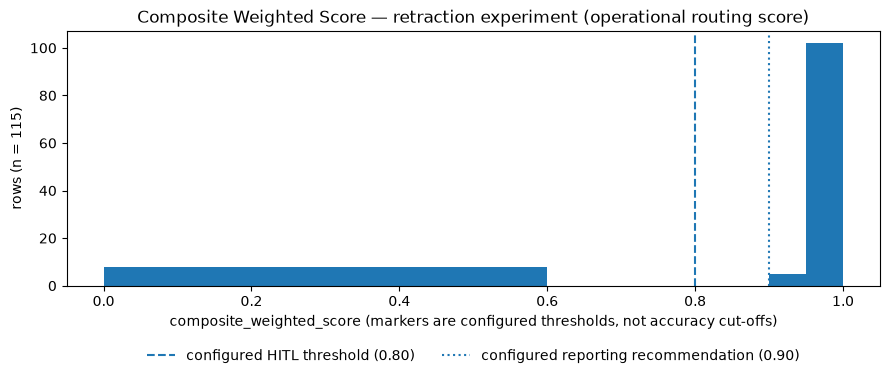

In [12]:
if ready():
    import matplotlib.pyplot as plt

    edges = [0.0, *config.reporting.score_band_edges, 1.0 + 1e-9]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(a["score"].dropna(), bins=edges)
    ax.axvline(config.scoring.hitl_threshold, linestyle="--",
               label=f"configured HITL threshold ({config.scoring.hitl_threshold:.2f})")
    ax.axvline(config.reporting.recommended_threshold, linestyle=":",
               label=f"configured reporting recommendation ({config.reporting.recommended_threshold:.2f})")
    ax.set_title("Composite Weighted Score — retraction experiment (operational routing score)")
    ax.set_xlabel("composite_weighted_score (markers are configured thresholds, not accuracy cut-offs)")
    ax.set_ylabel(f"rows (n = {int(a['score'].notna().sum())})")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
    plt.tight_layout(); plt.show()

## 13 — Scoring scenarios

The reliability-weight scenario the deterministic scorer selected per row. The pipeline's own
report artifact is used where it exists; otherwise the detailed audit supplies the same field.

In [13]:
if ready():
    scenario_report = PATHS["reports_dir"] / config.reporting.scenario_distribution_filename
    if scenario_report.exists():
        print(f"from report artifact: {_rel(scenario_report)}")
        display(pd.read_csv(scenario_report))
    else:
        print("report artifact absent — summarised from the detailed audit")
        display(a["scenario"].value_counts().rename_axis("scenario").to_frame("rows"))

from report artifact: models/swft_tc/outputs/retraction_experiment/reports/scenario_distribution.csv


,scenario,observation_count,percent_of_non_empty
0,both_explicit,107,93.04
1,town_explicit_country_ambiguous,4,3.48
2,town_explicit_country_inferred,3,2.61
3,town_inferred_country_ambiguous,1,0.87


## 14 — Cross-entropy and grounding

Cross-entropy measures whether the model's confidence matched reality, and it is meaningful
**only where independent evidence exists**. A row without grounding is excluded from the loss —
it is a coverage gap, not a model error, and nothing here treats it as one. Lower is better, the
opposite direction to the composite score.

In [14]:
if ready():
    ce = as_num(a[C["cross_entropy"]])
    grounded_any = ce.notna()
    tg = a["town_grounded"].fillna(False).astype(bool)
    cg = a["country_grounded"].fillna(False).astype(bool)
    N = len(a)
    display(pd.DataFrame(
        [
            ("Rows with a cross-entropy value (any grounding)", pct(int(grounded_any.sum()), N)),
            ("  Town-grounded", pct(int(tg.sum()), N)),
            ("  Country-grounded", pct(int(cg.sum()), N)),
            ("  fully grounded (both)", pct(int((tg & cg).sum()), N)),
            ("Rows without sufficient grounding (excluded from loss)", pct(int((~grounded_any).sum()), N)),
            ("Mean cross-entropy (grounded only, lower is better)", round(float(ce.mean()), 4) if grounded_any.any() else "n/a"),
            ("Median cross-entropy (grounded only)", round(float(ce.median()), 4) if grounded_any.any() else "n/a"),
        ],
        columns=["observed", "value"],
    ))
    ce_report = PATHS["reports_dir"] / config.reporting.cross_entropy_summary_filename
    if ce_report.exists():
        print(f"pipeline report: {_rel(ce_report)}"); display(pd.read_csv(ce_report))

,observed,value
0,Rows with a cross-entropy value (any grounding),113 (98.3%)
1,Town-grounded,96 (83.5%)
2,Country-grounded,109 (94.8%)
3,fully grounded (both),92 (80.0%)
4,Rows without sufficient grounding (excluded from loss),2 (1.7%)
5,"Mean cross-entropy (grounded only, lower is better)",0.1362
6,Median cross-entropy (grounded only),0.01


pipeline report: models/swft_tc/outputs/retraction_experiment/reports/cross_entropy_summary.csv


,metric,value,denominator
0,Non-empty instances,115.000000,instances
1,Grounded observations,113.000000,instances with any ground truth
2,Ungrounded (excluded from loss),2.000000,instances
3,Mean cross-entropy,0.136200,grounded observations — lower is better
4,Median cross-entropy,0.010050,grounded observations — lower is better
5,P95 cross-entropy,1.025293,grounded observations — lower is better
6,Town correctness rate,100.000000,96 town-grounded instances
7,Country correctness rate,94.500000,109 country-grounded instances


## 15 — Prioritised manual-review set

One table, highest priority first: possible entity/location collision, then repeated Country,
repeated Town, low composite score, then reference conflict or ambiguity. `review_reasons` lists
every reason that applies.

In [15]:
if ready():
    from models.swft_tc.src.scoring import HITL_AMBIGUOUS_COUNTRY, HITL_REFERENCE_CONFLICT

    state = a[C["hitl_state"]]
    reasons = {
        "possible_entity_location_collision": a["possible_entity_location_collision"],
        "repeated_country": a["repeated_country_review_candidate"],
        "repeated_town": a["repeated_town_review"],
        "low_composite_score": a["score"].lt(config.scoring.hitl_threshold) & a["retraction_changed"],
        "hitl_reference_conflict": state.eq(HITL_REFERENCE_CONFLICT),
        "hitl_ambiguous_country": state.eq(HITL_AMBIGUOUS_COUNTRY),
    }
    priority = {name: rank for rank, name in enumerate(reasons)}
    a["review_reasons"] = [
        ",".join(name for name, mask in reasons.items() if mask.iloc[i]) for i in range(len(a))
    ]
    a["review_priority"] = [
        min((priority[r] for r in rs.split(",") if r), default=len(priority))
        for rs in a["review_reasons"]
    ]
    REVIEW_COLUMNS = [
        *ADDRESS_VIEW, C["predicted_town"], C["predicted_country"], C["predicted_country_name"],
        C["predicted_town_probability"], C["predicted_country_probability"],
        C["composite_weighted_score"], C["hitl_state"], C["combined_address_cleaned"],
        C["combined_address_retracted"], C["combined_address_retracted_comments"], "review_reasons",
    ]
    manual_review = (
        a.loc[a["review_reasons"].ne("")]
        .sort_values(["review_priority", "score"], ascending=[True, True])[REVIEW_COLUMNS]
        .reset_index(drop=True)
    )
    print("review reasons (a row may carry several):")
    display(pd.DataFrame({n: [int(m.sum())] for n, m in reasons.items()}, index=["rows"]).T)
    show(manual_review, n=20)

review reasons (a row may carry several):


,rows
possible_entity_location_collision,95
repeated_country,71
repeated_town,55
low_composite_score,7
hitl_reference_conflict,6
hitl_ambiguous_country,5


115 row(s) — showing 20


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,predicted_country_name_group_1,predicted_town_probability_group_1,predicted_country_probability_group_1,composite_weighted_score_group_1,HITL_state_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1,combined_address_retracted_group_comments_1,review_reasons
0,1117,DA AFGHANISTAN BANK-KABUL HO,IBNI SINA WATT,KABUL KABUL AF,BOCA CHICA SANTO DOMINGO DO,KABUL,"AF,DO","Afghanistan,Dominican Republic",0.8,0.0,0.0,HITL_AMBIGUOUS_COUNTRY,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL KABUL AF BOCA CH...,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL AF BOCA CHICA SA...,Retracted Town=KABUL. Country was not explicitly verified in the i...,"possible_entity_location_collision,repeated_town,low_composite_sco..."
1,1167,BANCO CONTINENTAL SAECA-ASUNCION HO,3233 AVENIDA MARISCAL LOPEZ,ASUNCION ASUNCION 001411 PY,SANTO DOMINGO DISTRITO NACIONAL DO,ASUNCION,"DO,PY","Dominican Republic,Paraguay",0.85,0.0,0.0,HITL_AMBIGUOUS_COUNTRY,BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...,BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...,Retracted Town=ASUNCION. Country was not explicitly verified in th...,"possible_entity_location_collision,repeated_town,low_composite_sco..."
2,1211,PASHTANY BANK-KABUL HEAD OFFICE,MUHAMMAD JAN KHAN WAT HEADQUARTERS,KABUL KABUL AF,PANAMA CITY PANAMA 0831-02604 PA,KABUL,"AF,PA","Afghanistan,Panama",0.5,0.0,0.0,HITL_AMBIGUOUS_COUNTRY,PASHTANY BANK-KABUL HEAD OFFICE MUHAMMAD JAN KHAN WAT HEADQUARTERS...,PASHTANY BANK-KABUL HEAD OFFICE MUHAMMAD JAN KHAN WAT HEADQUARTERS...,Retracted Town=KABUL. Country was not explicitly verified in the i...,"possible_entity_location_collision,repeated_town,low_composite_sco..."
3,2253,CITIBANK CANADA ELIMINATION VEHICLE,"SUITE 1900, CITIBANK PLACE",123 FRONT ST WEST,CENTRAL HONG KONG,CENTRAL,"CA,HK","Canada,Hong Kong",0.8,0.0,0.0,HITL_AMBIGUOUS_COUNTRY,"CITIBANK CANADA ELIMINATION VEHICLE SUITE 1900, CITIBANK PLACE 123...","CITIBANK CANADA ELIMINATION VEHICLE SUITE 1900, CITIBANK PLACE 123...",Retracted Town=CENTRAL. Country was not explicitly verified in the...,"possible_entity_location_collision,low_composite_score,hitl_ambigu..."
4,1049,Citibank NA Abu Dhabi GM,ABU DHABI GLOBAL MARKET SQUARE,AL SILA TOWER,,ABU DHABI,AE,United Arab Emirates,0.99,0.95,0.35268749999999993,HITL_LOW_SCORE,Citibank NA Abu Dhabi GM ABU DHABI GLOBAL MARKET SQUARE AL SILA TOWER,Citibank NA Abu Dhabi GM GLOBAL MARKET SQUARE AL SILA TOWER,Retracted Town=ABU DHABI. Country was not explicitly verified in t...,"possible_entity_location_collision,repeated_town,low_composite_score"
5,1108,CAUCEDO MARINE SERVICE LTD,ZONA FRANCA MULTIMODAL CAUCEDO,SANTO DOMINGO,,SANTO DOMINGO,DO,Dominican Republic,0.99,0.95,0.35268749999999993,HITL_LOW_SCORE,CAUCEDO MARINE SERVICE LTD ZONA FRANCA MULTIMODAL CAUCEDO SANTO DO...,CAUCEDO MARINE SERVICE LTD ZONA FRANCA MULTIMODAL CAUCEDO,Retracted Town=SANTO DOMINGO. Country was not explicitly verified ...,"possible_entity_location_collision,low_composite_score"
6,1150,BANK OF BAGHDAD COMPANY/PRIVATE,SHAREHOLDING BUILDING 25/27,AL-NIDAL STREET 11 BAGHDAD,,BAGHDAD,IQ,Iraq,0.99,0.95,0.35268749999999993,HITL_LOW_SCORE,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...,Retracted Town=BAGHDAD. Country was not explicitly verified in the...,"possible_entity_location_collision,repeated_town,low_composite_score"
7,1212,BANCO LAFISE PANAMA SA,SANTA MARIA GOLF & COUNTRY CLUB,BUSINESS DISTRICT EDIFICIO LAFISE,,PANAMA,PA,Panama,0.95,0.95,0.9025,HITL_REFERENCE_CONFLICT,BANCO LAFISE PANAMA SA SANTA MARIA GOLF & COUNTRY CLUB BUSINESS DI...,BANCO LAFISE SA SANTA MARIA GOLF & COUNTRY CLUB BUSINESS DISTRICT ...,Retracted Town=PANAMA. Country was not explicitly verified in the ...,"possible_entity_location_collision,hitl_reference_confl

## 16 — Retraction risk cohorts

Small, separately addressable slices for the next experiment. A few example rows each.

In [16]:
if ready():
    COHORT_VIEW = [*ADDRESS_VIEW, C["predicted_town"], C["predicted_country"],
                   C["combined_address_cleaned"], C["combined_address_retracted"]]
    outcome = a["retraction_outcome"]
    cohorts = {
        "A. repeated Town": a["repeated_town_review"],
        "B. repeated Country": a["repeated_country_review_candidate"],
        "C. possible organisation/location collision": a["possible_entity_location_collision"],
        "D. Country removed, Town retained": outcome.eq("COUNTRY_ONLY_RETRACTION"),
        "E. Town removed, Country retained": outcome.eq("TOWN_ONLY_RETRACTION"),
        "F. both removed": outcome.eq("TOWN_AND_COUNTRY_RETRACTION"),
        "G. nothing removed": outcome.eq("NO_RETRACTION"),
        "H. HITL reference conflict": state.eq(HITL_REFERENCE_CONFLICT),
        "I. HITL ambiguity": state.eq(HITL_AMBIGUOUS_COUNTRY),
    }
    cohort_frames = {name: a.loc[mask, COHORT_VIEW] for name, mask in cohorts.items()}
    display(pd.DataFrame({n: [len(f)] for n, f in cohort_frames.items()}, index=["rows"]).T)
    for name, frame in cohort_frames.items():
        print(f"\n{name}"); show(frame, n=5)

,rows
A. repeated Town,55
B. repeated Country,71
C. possible organisation/location collision,95
"D. Country removed, Town retained",0
"E. Town removed, Country retained",9
F. both removed,105
G. nothing removed,1
H. HITL reference conflict,6
I. HITL ambiguity,5



A. repeated Town
55 row(s) — showing 5


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1
1,1037,BANQUE DU CAIRE SAE-CAIRO HO,6 DR MOSTAFA ABU ZAHRA STREET,BEHIND SONESTA HOTEL BANQUE,ABU DHABI ABU DHABI AE,ABU DHABI,AE,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...,BANQUE DU CAIRE SAE-CAIRO HO 6 DR MOSTAFA ABU ZAHRA STREET BEHIND ...
2,1049,Citibank NA Abu Dhabi GM,ABU DHABI GLOBAL MARKET SQUARE,AL SILA TOWER,,ABU DHABI,AE,Citibank NA Abu Dhabi GM ABU DHABI GLOBAL MARKET SQUARE AL SILA TOWER,Citibank NA Abu Dhabi GM GLOBAL MARKET SQUARE AL SILA TOWER
4,1107,DP WORLD CALLAO SRL NUMERO,113 AVENIDA MANCO CAPAC CALLAO,EL CALLAO 07 PE,DIST NACIONAL SANTO DOM DO,CALLAO,PE,DP WORLD CALLAO SRL NUMERO 113 AVENIDA MANCO CAPAC CALLAO EL CALLA...,DP WORLD CALLAO SRL NUMERO 113 AVENIDA MANCO CAPAC CALLAO EL 07 DI...
6,1117,DA AFGHANISTAN BANK-KABUL HO,IBNI SINA WATT,KABUL KABUL AF,BOCA CHICA SANTO DOMINGO DO,KABUL,"AF,DO",DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL KABUL AF BOCA CH...,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL AF BOCA CHICA SA...
8,1150,BANK OF BAGHDAD COMPANY/PRIVATE,SHAREHOLDING BUILDING 25/27,AL-NIDAL STREET 11 BAGHDAD,,BAGHDAD,IQ,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...,BANK OF BAGHDAD COMPANY/PRIVATE SHAREHOLDING BUILDING 25/27 AL-NID...



B. repeated Country
71 row(s) — showing 5


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1
3,1062,JAGUAR ENERGY GUATEMALA LLC,2 CALLE 05-77 NIVEL 4 EDIFICIO,ALTUM GUATEMALA CITY GUATEMALA GT,,GUATEMALA CITY,GT,JAGUAR ENERGY GUATEMALA LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM G...,JAGUAR ENERGY LLC 2 CALLE 05-77 NIVEL 4 EDIFICIO ALTUM
10,1192,ZONA FRANCA MULTIMODAL CAUCEDO SA,PUNTA CAUCEDO,EDIFICIO ADMINISTRATIVO,PANAMA CITY PANAMA PA,PANAMA CITY,PA,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...,ZONA FRANCA MULTIMODAL CAUCEDO SA PUNTA CAUCEDO EDIFICIO ADMINISTR...
14,1233,THE CO-OPER BK OF KE LTD NAIROBI HO,CO-OPERATIVE HOUSE,HAILE SELASSIE AVE,NAIROBI NAIROBI CITY 00100 KE,NAIROBI,KE,THE CO-OPER BK OF KE LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELAS...,THE CO-OPER BK OF LTD NAIROBI HO CO-OPERATIVE HOUSE HAILE SELASSIE...
15,1242,NESTLE GUATEMALA SA,157448 CALLE GUATEMALA CITY,GUATEMALA 01012 GT,,GUATEMALA CITY,GT,NESTLE GUATEMALA SA 157448 CALLE GUATEMALA CITY GUATEMALA 01012 GT,NESTLE SA 157448 CALLE 01012
18,1285,AEROVIAS DE MEXICO SA DE CV,AV PASEO DE LA REFORMA NUMERO 243,CUAUHTEMOC MEXICO CITY 06500 MX,,MEXICO CITY,MX,AEROVIAS DE MEXICO SA DE CV AV PASEO DE LA REFORMA NUMERO 243 CUAU...,AEROVIAS DE SA DE CV AV PASEO DE LA REFORMA NUMERO 243 CUAUHTEMOC ...


...

,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1
0,1000,ABU DHABI INVESTMENT AUTHORITY,211 CORNICHE STREET ABU DHABI,ABU DHABI 3600 AE,DU CAIRE TOWER CAIRO CAIRO 11371 EG,NO_TOWN,"AE,EG",ABU DHABI INVESTMENT AUTHORITY 211 CORNICHE STREET ABU DHABI ABU D...,ABU DHABI INVESTMENT AUTHORITY 211 CORNICHE STREET ABU DHABI ABU D...



H. HITL reference conflict
6 row(s) — showing 5


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1
13,1212,BANCO LAFISE PANAMA SA,SANTA MARIA GOLF & COUNTRY CLUB,BUSINESS DISTRICT EDIFICIO LAFISE,,PANAMA,PA,BANCO LAFISE PANAMA SA SANTA MARIA GOLF & COUNTRY CLUB BUSINESS DI...,BANCO LAFISE SA SANTA MARIA GOLF & COUNTRY CLUB BUSINESS DISTRICT ...
16,1264,BOGOTA DISTRITO CAPITAL - DIRECCION,DISTRITAL DE TESORERIA 25-90,CARRERA 30 NUMERO BOGOTA DISTRITO,CAPITAL DE BOGOTA 111311 CO,BOGOTA,CO,BOGOTA DISTRITO CAPITAL - DIRECCION DISTRITAL DE TESORERIA 25-90 C...,BOGOTA DISTRITO CAPITAL - DIRECCION DISTRITAL DE TESORERIA 25-90 C...
19,1287,AUTORIDAD DEL CANAL DE PANAMA,ANCON EDIFICIO DE LA,ADMINISTRACION BALBOA PANAMA PA,,PANAMA,PA,AUTORIDAD DEL CANAL DE PANAMA ANCON EDIFICIO DE LA ADMINISTRACION ...,AUTORIDAD DEL CANAL DE ANCON EDIFICIO DE LA ADMINISTRACION BALBOA
50,1886,GRUPO ENERGIA BOGOTA SA,ESP 73-44 CARRERA 9 PISO 6 BOGOTA,DISTRITO CAPITAL DE BOGOTA CO,,BOGOTA,CO,GRUPO ENERGIA BOGOTA SA ESP 73-44 CARRERA 9 PISO 6 BOGOTA DISTRITO...,GRUPO ENERGIA BOGOTA SA ESP 73-44 CARRERA 9 PISO 6 BOGOTA DISTRITO...
77,2235,KRAFT HEINZ CANADA ULC,96 MOATFIELD DRIVE SUITE 316,"NORTH YORK, ONTARIO",M3B 3L6 CANADA,NORTH YORK,CA,"KRAFT HEINZ CANADA ULC 96 MOATFIELD DRIVE SUITE 316 NORTH YORK, ON...",KRAFT HEINZ ULC 96 MOATFIELD DRIVE SUITE 316 ONTARIO M3B 3L6



I. HITL ambiguity
5 row(s)


,RECORD_ID,address_line_1,address_line_2,address_line_3,address_line_4,predicted_town_group_1,predicted_country_group_1,combined_address_cleaned_group_1,combined_address_retracted_group_1
0,1000,ABU DHABI INVESTMENT AUTHORITY,211 CORNICHE STREET ABU DHABI,ABU DHABI 3600 AE,DU CAIRE TOWER CAIRO CAIRO 11371 EG,NO_TOWN,"AE,EG",ABU DHABI INVESTMENT AUTHORITY 211 CORNICHE STREET ABU DHABI ABU D...,ABU DHABI INVESTMENT AUTHORITY 211 CORNICHE STREET ABU DHABI ABU D...
6,1117,DA AFGHANISTAN BANK-KABUL HO,IBNI SINA WATT,KABUL KABUL AF,BOCA CHICA SANTO DOMINGO DO,KABUL,"AF,DO",DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL KABUL AF BOCA CH...,DA AFGHANISTAN BANK-KABUL HO IBNI SINA WATT KABUL AF BOCA CHICA SA...
9,1167,BANCO CONTINENTAL SAECA-ASUNCION HO,3233 AVENIDA MARISCAL LOPEZ,ASUNCION ASUNCION 001411 PY,SANTO DOMINGO DISTRITO NACIONAL DO,ASUNCION,"DO,PY",BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...,BANCO CONTINENTAL SAECA-ASUNCION HO 3233 AVENIDA MARISCAL LOPEZ AS...
12,1211,PASHTANY BANK-KABUL HEAD OFFICE,MUHAMMAD JAN KHAN WAT HEADQUARTERS,KABUL KABUL AF,PANAMA CITY PANAMA 0831-02604 PA,KABUL,"AF,PA",PASHTANY BANK-KABUL HEAD OFFICE MUHAMMAD JAN KHAN WAT HEADQUARTERS...,PASHTANY BANK-KABUL HEAD OFFICE MUHAMMAD JAN KHAN WAT HEADQUARTERS...
82,2253,CITIBANK CANADA ELIMINATION VEHICLE,"SUITE 1900, CITIBANK PLACE",123 FRONT ST WEST,CENTRAL HONG KONG,CENTRAL,"CA,HK","CITIBANK CANADA ELIMINATION VEHICLE SUITE 1900, CITIBANK PLACE 123...","CITIBANK CANADA ELIMINATION VEHICLE SUITE 1900, CITIBANK PLACE 123..."


## 17 — Baseline findings

Generated from the values above, so the numbers cannot drift from the tables.

In [17]:
if ready():
    N = len(a)
    lines = [
        f"- {int(a['retraction_changed'].sum())} / {N} records had any deterministic retraction",
        f"- {int(a['repeated_town_review'].sum())} contained repeated Town evidence "
        f"(one occurrence removed, the rest retained by the one-per-group rule)",
        f"- {int(a['repeated_country_review_candidate'].sum())} were repeated-Country review candidates "
        f"(every verified occurrence removed — the uncapped rule)",
        f"- {int(a['possible_entity_location_collision'].sum())} were possible entity/location collision review candidates",
        f"- {int(as_bool(a[C['hitl_flag']]).sum())} were routed to HITL; "
        f"{int(state.eq(HITL_AMBIGUOUS_COUNTRY).sum())} for unresolved country ambiguity, "
        f"{int(state.eq(HITL_REFERENCE_CONFLICT).sum())} for a reference conflict",
        f"- {int((~as_num(a[C['cross_entropy']]).notna()).sum())} rows carry no independent grounding and are "
        f"excluded from every quality statement above",
        "",
        "These cohorts identify where entity-aware protection should be evaluated against the "
        "deterministic baseline. Nothing here establishes that the baseline is wrong on any row: "
        "that needs independently labelled ground truth, which this experiment does not have.",
    ]
    print("\n".join(lines))

- 114 / 115 records had any deterministic retraction
- 55 contained repeated Town evidence (one occurrence removed, the rest retained by the one-per-group rule)
- 71 were repeated-Country review candidates (every verified occurrence removed — the uncapped rule)
- 95 were possible entity/location collision review candidates
- 14 were routed to HITL; 5 for unresolved country ambiguity, 6 for a reference conflict
- 2 rows carry no independent grounding and are excluded from every quality statement above

These cohorts identify where entity-aware protection should be evaluated against the deterministic baseline. Nothing here establishes that the baseline is wrong on any row: that needs independently labelled ground truth, which this experiment does not have.


## 18 — Comparing against a future entity-protected run

The next experiment will produce its own canonical output. This helper lines the two up by
`RECORD_ID` and reports where the retracted address differs. It needs nothing that does not exist
yet; the demonstration below compares the baseline with itself.

In [18]:
def compare_retraction_outputs(
    baseline_df: pd.DataFrame,
    entity_df: pd.DataFrame,
    record_id: str = RECORD_ID,
    retracted_column: str = C["combined_address_retracted"],
) -> pd.DataFrame:
    """Row-by-row retraction comparison between two runs of the same input.

    Returns one row per RECORD_ID present in either frame, with the baseline and
    entity-protected retracted address and a `changed` flag. IDs missing from one
    side are kept, with `present_in` saying which side had them, so a dropped or
    added record is visible rather than silently discarded.
    """
    left = baseline_df[[record_id, retracted_column]].rename(
        columns={retracted_column: "baseline_retracted_address"})
    right = entity_df[[record_id, retracted_column]].rename(
        columns={retracted_column: "entity_retracted_address"})
    merged = left.merge(right, on=record_id, how="outer", indicator="present_in")
    merged["present_in"] = merged["present_in"].map(
        {"both": "both", "left_only": "baseline_only", "right_only": "entity_only"})
    merged["changed"] = (
        merged["present_in"].ne("both")
        | merged["baseline_retracted_address"].ne(merged["entity_retracted_address"])
    )
    return merged[[record_id, "baseline_retracted_address", "entity_retracted_address",
                   "changed", "present_in"]]


if ready():
    demo = compare_retraction_outputs(df, df)
    print(f"self-comparison: {len(demo)} rows, {int(demo['changed'].sum())} changed (expected 0)")
    # Later: entity_df = pd.read_csv(<entity-protected output>, dtype=str, keep_default_na=False)
    #        compare_retraction_outputs(df, entity_df).query("changed")

self-comparison: 115 rows, 0 changed (expected 0)


## 19 — Optional export of the manual-review set

Off by default. Flip `EXPORT_REVIEW` to `True` to write the prioritised review table beside the
other experiment artifacts (git-ignored: it carries raw addresses).

In [19]:
EXPORT_REVIEW = False

if EXPORT_REVIEW and ready():
    export_path = OUTPUT_ROOT / f"{_prefix}_manual_review.csv"
    manual_review.to_csv(export_path, index=False, encoding="utf-8")
    print(f"wrote {len(manual_review)} rows -> {_rel(export_path)}")
else:
    print("Review export disabled.")

Review export disabled.
